In [ ]:
!pip install PyPDF2

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 232.6/232.6 kB 4.2 MB/s eta 0:00:00


In [ ]:
from sqlalchemy import create_engine
from PyPDF2 import PdfReader
import pandas as pd
import os
import psycopg2
from pprint import pprint
from tqdm.auto import trange
from google.colab import drive
from datetime import datetime
import numpy as np
from itertools import product
import requests
import json

In [ ]:
drive.mount('/content/drive')
os.chdir('/content/drive/My Drive/Colab Notebooks/GSMLS')

Mounted at /content/drive


In [ ]:
# Create connections for sqlalchemy to get data tax and residential data
tax_engine = create_engine(f"postgresql+psycopg2://postgres:pw@hostname:5433/nj_tax_assessor")
gsmls_engine = create_engine(f"postgresql+psycopg2://postgres:pw@hostname:5433/gsmls")

In [ ]:
# Load the GSMLS data from PostgreSQL
query = """SELECT * FROM res_properties
          WHERE \"LATITUDE\" != '0E-20' AND \"LONGITUDE\" != '0E-20';
          """
gsmls_data = pd.read_sql_query(query, gsmls_engine)

In [ ]:
change_dtype_dict = {
    'LATITUDE': 'float64',
    'LONGITUDE': 'float64',
    'BEDS': 'float64',
    'SALESPRICE': 'float64',
    'ORIGLISTPRICE': 'float64',
    'FIREPLACES': 'float64'
}

In [ ]:
# Initial data filtering to remove rows with feature that equals infinity and removing duplicate rows (if any)
gsmls_data = gsmls_data.astype(change_dtype_dict)
gsmls_data = gsmls_data[(gsmls_data['OLP/LP%'] < np.inf)]
gsmls_data.drop_duplicates(subset=['MLSNUM'], keep='last', inplace=True)

In [ ]:
gsmls_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 913202 entries, 1112 to 1188731
Columns: 173 entries, MLSNUM to LISTING_REMARKS
dtypes: bool(102), datetime64[ns](4), float64(24), int64(8), object(35)
memory usage: 590.5+ MB


In [ ]:
pd.set_option('display.max_columns', 999)

In [ ]:
# Will use FLOODZONE column at a later date
skip_columns = ['SP/OLP%', 'LOANTERMS_SHORT', 'BATHSFULLTOTAL', 'BATHSHALFTOTAL', 'LOTSIZE', 'SUBDIVISION',
                'PENDINGDATE', 'ANTICCLOSEDDATE', 'EXPIREDATE', 'WITHDRAWNDATE', 'OWNERSHIP_SHORT',
                'FLOODZONE', 'ZONING', 'COMPBUY', 'COMPSELL', 'COMPTRANS', 'LISTTYPE_SHORT', 'OFFICELIST', 'OFFICESELL',
                'OFFICESELLNAME', 'AGENTSELLNAME', 'SELLERNAME', 'AGENTLIST', 'AGENTSELL', 'BUSRELATION_SHORT', 'MLS', 'PARKNBRAVAIL']

### Parse a PDF to enrich the dataframe with the correct county codes

In [ ]:
# Function which accepts a string variable as an argument and parses it to seperate the county name and county code

def parse_data(string_var):

  data = string_var.split(' ')

  county_data = []

  for idx, item in enumerate(data):

    # If the item is numeric and in the first index of the list, seperate the county id
    if item.isnumeric():
      if idx == 0:
        code = item
        if code[:2] not in nj_dict['county_code']:
          nj_dict['county_code'].append(code[:2])

    elif item.isalpha():

      # If the item is upper case, data is valuable
      if item == item.upper():
        pass

      else:
        # If the item is alpha and not upper case, append to the new list for further cleaning
        county_data.append(item)

  try:
      if (county_data[-2] == 'Count') and county_data[-1] == 'y':
        county_data.pop(-1)
        county_data[-1] = 'County'

  except IndexError as ie:
      pass

  else:
    county = ' '.join(county_data)
    if (county not in nj_dict['county']) and (county.split(' ')[0] != county.split(' ')[1]) and (county.split(' ')[-1] != 'Count') and (county.split(' ')[-1] != 'Codes'):
      nj_dict['county'].append(county)

In [ ]:
# Extract data from the pdf

nj_dict = {
    'county_code': [],
    'county': []
}

pdf_doc = PdfReader('NJ Municipal Codes.pdf')

number_of_pages = len(pdf_doc.pages)

for i in range(number_of_pages):
    page = pdf_doc.pages[i]
    page_info = page.extract_text()
    text_list = page_info.split('\n')

    for city in text_list:
      parse_data(city)

### Enrich dataframe with mortgage rates by requesting the data from the FREDs API

In [ ]:
def get_mortgage_rates():
  """Use this function to get the mortgage rates from fred"""

  freds_api_key = 'my_api_key'
  freds_api = f'https://api.stlouisfed.org/fred/series/observations?series_id=MORTGAGE30US&api_key={freds_api_key}&file_type=json&observation_start=1994-01-01&observation_end=9999-12-31'

  mortgage_data = requests.get(freds_api)
  mortgage_json = json.loads(mortgage_data.text)
  mortgage_df = pd.DataFrame(mortgage_json['observations'])
  mortgage_df.drop(columns=['realtime_start', 'realtime_end'], inplace=True)
  mortgage_df['date'] = pd.to_datetime(mortgage_df['date'])
  mortgage_df.set_index('date', inplace=True)

  return mortgage_df

In [ ]:
mortgage_df = get_mortgage_rates()
mortgage_df.tail(10)

,value
date,
2025-03-20,6.67
2025-03-27,6.65
2025-04-03,6.64
2025-04-10,6.62
2025-04-17,6.83
2025-04-24,6.81
2025-05-01,6.76
2025-05-08,6.76
2025-05-15,6.81


In [ ]:
temp_df = gsmls_data.copy()

In [ ]:
# Impute the mortgage data to the main df

gsmls_data['MORTGAGE_RATE'] = 0.0

for start_date, value in mortgage_df.iterrows():

  end_date = start_date + pd.Timedelta('7 days')
  target_df = temp_df[(temp_df['LISTDATE'] >= start_date) & (temp_df['LISTDATE'] < end_date)]

  if target_df.empty:
    continue

  else:
    gsmls_data.loc[target_df.index, 'MORTGAGE_RATE'] = value['value']

gsmls_data.insert(17, 'MORTGAGE_RATE', gsmls_data.pop('MORTGAGE_RATE'))
gsmls_data['MORTGAGE_RATE'] = gsmls_data['MORTGAGE_RATE'].astype('float64')

<ipython-input-16-a5de2ffd3aa4>:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  gsmls_data['MORTGAGE_RATE'] = 0.0
<ipython-input-16-a5de2ffd3aa4>:14: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '7.23' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  gsmls_data.loc[target_df.index, 'MORTGAGE_RATE'] = value['value']
<ipython-input-16-a5de2ffd3aa4>:16: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  gsmls_dat

In [ ]:
def create_nj_county_code(df):
  """Use this function to create a new column with the nj town codes"""

  df['NJ_COUNTY_CODE'] = 'None'

  for code, county in zip(nj_dict['county_code'], nj_dict['county']):
    mask = df[df['COUNTY'] == f'{county[:-7]}']
    # print(f'{county[:-7]}')

    if mask.empty:
      pass

    else:
      df.loc[mask.index, 'NJ_COUNTY_CODE'] = code

  return df



In [ ]:
def create_nj_town_code(df):
  """Use this function to create a new column with the nj town codes"""

  df['NJ_TOWNCODE'] = 'None'

  for idx, row in df.iterrows():

    value = str(row['TOWNCODE'])[-2:]

    df.loc[idx, 'NJ_TOWNCODE'] = row['NJ_COUNTY_CODE'] + value

  df.pop('NJ_COUNTY_CODE')
  df.insert(7, 'NJ_TOWNCODE', df.pop('NJ_TOWNCODE'))

  return df


In [ ]:
gsmls_data = gsmls_data[[i for i in gsmls_data.columns if i not in skip_columns]]

In [ ]:
gsmls_data = create_nj_county_code(gsmls_data)
gsmls_data = create_nj_town_code(gsmls_data)

<ipython-input-18-1a15ded90d9a>:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['NJ_COUNTY_CODE'] = 'None'
<ipython-input-19-07a0c5e5941e>:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['NJ_TOWNCODE'] = 'None'
<ipython-input-19-07a0c5e5941e>:13: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  

In [ ]:
print(f'Codes: {len(nj_dict["county_code"])}')
print(f'Counties: {len(nj_dict["county"])}')

Codes: 21
Counties: 21


In [ ]:
# Fix the zipcode column
def fix_zipcodes(x):

  if '.' in x:
    x = x.split('.')[0]


  if len(x) >= 5:
    return x

  elif len(x) == 4:
    return '0' + x

  elif len(x) == 3:
    return '00' + x

  else:
    return x

In [ ]:
# Fix the Streetnum column
def fix_streetnum(x):

  if '.' in x:
    x = x.split('.')[0]
    return x

  else:
    return x

In [ ]:
gsmls_data['ZIPCODE'] = gsmls_data['ZIPCODE'].apply(fix_zipcodes)
gsmls_data['STREETNUMDISPLAY'] = gsmls_data['STREETNUMDISPLAY'].apply(fix_streetnum)
gsmls_data['ADDRESS'] = gsmls_data['STREETNUMDISPLAY'].str.cat(gsmls_data['STREETNAME'].str.title(), sep=' ')
gsmls_data.insert(2, 'ADDRESS', gsmls_data.pop('ADDRESS'))
gsmls_data.drop(columns=['STREETNUMDISPLAY', 'STREETNAME'], inplace=True)

<ipython-input-25-6e267c4a12e6>:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  gsmls_data['ADDRESS'] = gsmls_data['STREETNUMDISPLAY'].str.cat(gsmls_data['STREETNAME'].str.title(), sep=' ')
<ipython-input-25-6e267c4a12e6>:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  gsmls_data.insert(2, 'ADDRESS', gsmls_data.pop('ADDRESS'))


In [ ]:
gsmls_data.head(5)

,MLSNUM,STATUS_SHORT,ADDRESS,TOWN,COUNTY,ZIPCODE,NJ_TOWNCODE,TOWNCODE,COUNTYCODE,BLOCKID,LOTID,TAXID,LATITUDE,LONGITUDE,DAYSONMARKET,CONDITION,MORTGAGE_RATE,ORIGLISTPRICE,LISTPRICE,OLP/LP%,SALESPRICE,SP/LP%,INVESTMENT_SALE,POTENTIAL_INVESTMENT,DISTRESSED_SALE,SHORT_SALE,BANK_OWNED,ROOMS,BEDS,BATHSTOTAL,SQFTAPPROX,LOTSIZE (SQFT),ASSESSAMOUNTBLDG,ASSESSAMOUNTLAND,ASSESSTOTAL,TAXAMOUNT,SUBPROPTYPE_SFH,STYLEPRIMARY_SHORT,QTR,MONTH,YEAR,DAYS_TO_CLOSE,ANTIC_CLOSEDATE_DIFF,YEARBUILT,LISTDATE,CLOSEDDATE,EASEMENT_SHORT,GARAGECAP,FIREPLACES,POOL_SHORT,APPFEE,ASSOCFEE,WOOD_FLOORS,MARBLE_FLOORS,TILE_FLOORS,CARPET_FLOORS,VINYL_FLOORS,LAMINATE_FLOORS,STONE_FLOORS,PARQUET_FLOORS,OFF_STREET_PKNG,1_CAR_WIDE,2_CAR_WIDE,WINDOW_AC,CENTRAL_AC,1_UNIT_AC,2_UNITS_AC,3_UNITS_AC,WALL_UNIT_AC,CEILFAN_AC,DUCTLESS_AC,MULTIZONE_AC,HEAT_SRC_NATGAS,HEAT_SRC_ELECTRIC,HEAT_SRC_OILABV,HEAT_SRC_OILBEL,HEAT_SRC_SOLAR,BASEDESC_BILCOSTY,BASEDESC_FINISHED,BASEDESC_FINPART,BASEDESC_FRNCHDRN,BASEDESC_FULL,BASEDESC_PARTIAL,BASEDESC_SLAB,BASEDESC_UNFINISH,BASEDESC_WALKOUT,BASEDESC_NONE,EXTERIOR_SHORT_DECK,EXTERIOR_ENCLPRCH,EXTERIOR_FENCPRIV,EXTERIOR_FENCVNYL,EXTERIOR_FENCWOOD,EXTERIOR_GAZEBO,EXTERIOR_HOTTUB,EXTERIOR_METALFNC,EXTERIOR_OPENPRCH,EXTERIOR_OUTDRKIT,EXTERIOR_PATIO,EXTERIOR_PERGOLA,EXTERIOR_SPRINKLR,EXTERIOR_STORAGE,EXTERIOR_WORKSHOP,ROOF_ASPHSHNG,ROOF_COMPSHNG,ROOF_FLAT,SIDING_ALUMINUM,SIDING_BRICK,SIDING_CEDARSID,SIDING_CLAPBRD,SIDING_COMPSHNG,SIDING_COMPSIDE,SIDING_CONCBRD,SIDING_METAL,SIDING_STONE,SIDING_STUCCO,SIDING_VERTICAL,SIDING_VINYL,SIDING_WOOD,SIDING_WOODSHNG,HEATSYSTEM_1UNIT,HEATSYSTEMT_2UNITS,HEATSYSTEM_3UNITS,HEATSYSTEM_4UNITS,HEATSYSTEM_BSBDCAST,HEATSYSTEM_BSBDELEC,HEATSYSTEM_BSBDHOTW,HEATSYSTEM_FORCEDHA,HEATSYSTEM_MULTIZON,HEATSYSTEM_RDNTHOTW,HEATSYSTEM_RDTRHOTW,HEATSYSTEM_RDTRSTM,HEATSYSTEM_REGISTER,SEWER_ASSOCTN,SEWER_PUBLAVAL,SEWER_PUBLIC,SEWER_SEPTIC,WATER_ASSOCTN,WATER_PUBLIC,WATER_PRIVATE,WATER_WELL,WATER_WATRXTRA,UTILITIES_ALLUNDER,UTILITIES_ELECTRIC,UTILITIES_GASNATUR,UTILITIES_GASINSTR,UTILITIES_GASPROPN,LISTING_REMARKS
1112,3682130,SD,63 Pheasant Run,Edison Twp,Middlesex,08820-2939,1205,2105,21,593.08,8.01,2105-00593-0008-00008-0001-C0063,40.557391,-74.383314,49.0,Unknown,2.71,389000.0,389000,0.0,365000.0,-6.0,False,False,False,False,False,6.0,2.0,1.1,0.0,0.0,62100.0,58000.0,120100.0,6495.0,False,MultiFlr,1234,3,2021,4665600000000000,-172800000000000,1982.0,2020-12-04,2021-03-17,False,0.0,0.0,False,0.0,265.0,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,True,False,False,False,False,True,True,False,False,Pristine unit in lovely North Edison Pumptown ...
1113,3682615,WD,344 Plainfield Ave,Edison Twp,Middlesex,08817-3147,1205,2105,21,82,3.C,2105-00082-0000-00003-000C-,40.518015,-74.408396,119.0,Unknown,2.71,565000.0,565000,0.0,0.0,-100.0,False,False,False,False,False,10.0,3.0,3.0,0.0,20680.0,0.0,113700.0,0.0,6148.0,False,TwnEndUn,1234,0,0,-9223372036854775808,-9223372036854775808,2020.0,2020-12-10,NaT,False,0.0,0.0,False,0.0,0.0,True,False,True,False,False,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,True,False,True,False,True,False,False,False,False,True,False,False,False,True,True,False,True,False,True,False,False,True,False,False,False,True,False,False,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,True,True,False,False,False,False,False,False,True,False,False,True,False,False,False,False,False,True,False,False,New Luxury High End Very Big To

In [ ]:
import re
tax_id_pattern = re.compile(r'\d{4}-\d{5}-[0-9A-Z]*-\d{5}-[0-9A-Z]*-([0-9A-Z]*)?|0000-00000-0000-00000-0000')

gsmls_data['TAX_PATTERN'] = gsmls_data['TAXID'].str.count(tax_id_pattern)

<ipython-input-27-b3538c783588>:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  gsmls_data['TAX_PATTERN'] = gsmls_data['TAXID'].str.count(tax_id_pattern)


<Axes: >

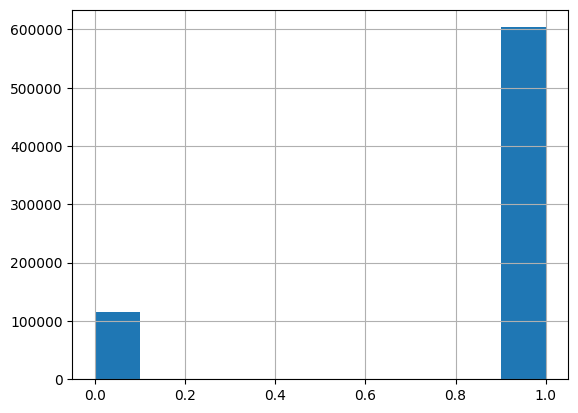

In [ ]:
# Isolate the instances which have a positive tax id pattern and doesnt equal the default value
# These will be the target properties to construct the pams_pin columns to clean the data easier through merging
# and or concat the STREETNUMDISPLAY and STREETNAME columns
gsmls_data[gsmls_data['TAXID'] != '0000-00000-0000-00000-0000']['TAX_PATTERN'].hist()

In [ ]:
style_types = gsmls_data.groupby('STYLEPRIMARY_SHORT')['SALESPRICE'].count()

In [ ]:
style_types

,SALESPRICE
STYLEPRIMARY_SHORT,
-1,2
AFrame,2110
Bi-Level,37979
Bungalow,2574
CapeCod,81764
Carriage,789
Chalet,1052
CnvStrct,216
Colonial,369857


In [ ]:
def parse_date(value):
  """Use this function to fix the month and year values"""

  date = str(value).split('-')
  month = int(date[1])
  year = int(date[0])

  return month, year

In [ ]:
def fix_housing_style(value):

  if value in ['SeeRem', 'Trailer', -1, '-1']:
    return 'Unknown'

  elif value == 'Ranch,RanchExp':
    return 'RanchExp'

  elif value == 'RanchRas,Ranch':
    return 'RanchRas'

  elif value == 'Victrian':
    return 'Victorian'

  elif value == 'Contemp':
    return 'Contemporary'

  elif value in ['FirstFlr', 'Hi-Rise', 'HighRise', 'MultiFlr', 'OneFloor']:
    return 'Condo'


In [ ]:
status_type = gsmls_data.groupby('STATUS_SHORT')['SALESPRICE'].count()

In [ ]:
status_type

,SALESPRICE
STATUS_SHORT,
S,17849
SD,537570
WD,128949
X,2054
XD,226780


In [ ]:
temp_data = gsmls_data.copy()

### Enrich the data with month and year data.
### Continue cleaning the dataframe by correcting the primary house type, market status and address

In [ ]:
for _, row in zip(trange(len(gsmls_data), desc='Rows'), temp_data.iterrows()):

  idx = row[0]
  data = row[1]
  try:
    # Parse the date for the Expired and Withdrawn data and impute the month and year
    if data['STATUS_SHORT'] not in ['S', 'SD']:
      month, year = parse_date(data['LISTDATE'])
      gsmls_data.loc[idx, 'MONTH'] = month
      gsmls_data.loc[idx, 'YEAR'] = year

    # Fix the house styles of a few data points
    if data['STYLEPRIMARY_SHORT'] in ['SeeRem', 'Ranch,RanchExp', 'RanchRas,Ranch', 'Trailer', 'Victrian', 'Contemp',
                                      'FirstFlr', 'Hi-Rise', 'HighRise', 'MultiFlr', 'OneFloor', -1, '-1']:
      gsmls_data.loc[idx, 'STYLEPRIMARY_SHORT'] = fix_housing_style(data['STYLEPRIMARY_SHORT'])

    if data['STATUS_SHORT'] in ['X', 'XD']:
      gsmls_data.loc[idx, 'STATUS_SHORT'] = 'EXP'

    elif data['STATUS_SHORT'] == 'S':
      gsmls_data.loc[idx, 'STATUS_SHORT'] = 'SD'
  except IndexError as ie:
    print(f'Index Error @ {data["ADDRESS"]} - {data["LISTDATE"]}: {ie}')


Rows:   0%|          | 0/913202 [00:00<?, ?it/s]

Index Error @ 5 Megan Terrace - NaT: list index out of range


In [ ]:
temp_data = gsmls_data.copy()

### Reclassify the some of the properties with "withdrawn" statuses with "expired". There are infinite reasons a property can be withdrawn, however, if the property has existed on the market past the 25th percentile of expired properties, it will be classified as "expired".

In [ ]:
min_year = gsmls_data['YEAR'].min()
max_year = gsmls_data['YEAR'].max()
years = list(gsmls_data['YEAR'].unique())
years.sort()

for _, year in zip(trange(len(gsmls_data['YEAR'].unique()), desc='Years'), years):

  try:
    # Create a dataframe with the year filtered
    year_data = temp_data[temp_data['YEAR'] == year]
    # Get the threshold of the bottom 25% of properties which expired
    reclassification_threshold = year_data[year_data['STATUS_SHORT'] == 'EXP']['DAYSONMARKET'].quantile(0.25)
    print(f'Reclassification Threshold for {year}: {reclassification_threshold}')
    # Create a mask to target those specific properties and change their status from WD to XD
    mask = gsmls_data[(gsmls_data['YEAR'] == year) & (gsmls_data['STATUS_SHORT'] == 'WD') & (gsmls_data['DAYSONMARKET'] >= reclassification_threshold)]
    gsmls_data.loc[mask.index, 'STATUS_SHORT'] = 'EXP'

  except ValueError as ve:
    print(f'ValueError for Year {year}: {ve}')



Years:   0%|          | 0/35 [00:00<?, ?it/s]

Reclassification Threshold for 0: nan
Reclassification Threshold for 1980: -7124.0
Reclassification Threshold for 1992: nan
Reclassification Threshold for 1993: 3767.0
Reclassification Threshold for 1995: nan
Reclassification Threshold for 1996: 2031.25
Reclassification Threshold for 1997: 1126.0
Reclassification Threshold for 1998: 731.0
Reclassification Threshold for 1999: 366.0
Reclassification Threshold for 2000: 176.0
Reclassification Threshold for 2001: 93.0
Reclassification Threshold for 2002: 92.0
Reclassification Threshold for 2003: 92.0
Reclassification Threshold for 2004: 92.0
Reclassification Threshold for 2005: 100.0
Reclassification Threshold for 2006: 93.0
Reclassification Threshold for 2007: 150.0
Reclassification Threshold for 2008: 178.0
Reclassification Threshold for 2009: 177.0
Reclassification Threshold for 2010: 181.0
Reclassification Threshold for 2011: 181.0
Reclassification Threshold for 2012: 182.0
Reclassification Threshold for 2013: 181.0
Reclassification Th

In [ ]:
status_type = gsmls_data.groupby('STATUS_SHORT')['SALESPRICE'].count()

In [ ]:
# Remove the rows with "XD" and "WD" values in STATUS_SHORT
status_type

,SALESPRICE
STATUS_SHORT,
EXP,276685
SD,555419
WD,81097
XD,1


In [ ]:
year_property_count = gsmls_data.groupby('YEAR')['STATUS_SHORT'].count()

In [ ]:
# Remove all data that was collected before the year 1996
year_property_count

,STATUS_SHORT
YEAR,
0,1
1980,11
1992,1
1993,1
1995,16
1996,2384
1997,14967
1998,20031
1999,18488


### Create filters for the target data based on the upper and lower limits of each feature

In [ ]:
target_col = ['DAYSONMARKET', 'LISTPRICE', 'OLP/LP%', 'SALESPRICE', 'ROOMS',
              'SQFTAPPROX', 'LOTSIZE (SQFT)', 'BEDS', 'BATHSTOTAL',
              'ASSESSAMOUNTLAND', 'ASSESSAMOUNTBLDG', 'ASSESSTOTAL', 'TAXAMOUNT',
              'YEARBUILT', 'GARAGECAP', 'APPFEE', 'ASSOCFEE', 'LATITUDE', 'LONGITUDE',
              'ORIGLISTPRICE', 'MONTH', 'YEAR', 'FIREPLACES']

iqr_dict = {
    'col': [],
    'q1': [],
    'q3': [],
    'iqr': [],
    'lower_bound': [],
    'upper_bound': [],
    'min': [],
    'max': [],
    'skew': []
}

for col in target_col:
  max_val = first_filtered_data[col].max()
  min_val =first_filtered_data[col].min()
  skew = first_filtered_data[col].skew()
  q1 = int(first_filtered_data[col].quantile([0.25]).values[0])
  q3 = int(first_filtered_data[col].quantile([0.75]).values[0])
  iqr = q3 - q1
  lower_bound = q1 - (1.5 * iqr)
  upper_bound = q3 + (1.5 * iqr)
  iqr_dict['col'].append(col)
  iqr_dict['q1'].append(q1)
  iqr_dict['q3'].append(q3)
  iqr_dict['iqr'].append(iqr)
  iqr_dict['lower_bound'].append(lower_bound)
  iqr_dict['upper_bound'].append(upper_bound)
  iqr_dict['max'].append(max_val)
  iqr_dict['min'].append(min_val)
  iqr_dict['skew'].append(skew)

iqr_df = pd.DataFrame(iqr_dict)
iqr_df.set_index('col', inplace=True)

In [ ]:
"""
Imputations for the current data:
DAYSONMARKET: mean for that year and location
SQFTAPPROX: nj_tax_data and if that doesnt work, mean for that year and location
"""
iqr_df

,q1,q3,iqr,lower_bound,upper_bound,min,max,skew
col,,,,,,,,
DAYSONMARKET,27,181,154,-204.0,412.0,0.000000,9.000000e+02,1.841200
LISTPRICE,239900,529900,290000,-195100.0,964900.0,10000.000000,7.995000e+06,3.083123
OLP/LP%,-4,0,4,-10.0,6.0,-59.000000,5.900000e+01,-2.322359
SALESPRICE,0,425000,425000,-637500.0,1062500.0,0.000000,5.000000e+06,1.870740
ROOMS,6,9,3,1.5,13.5,2.000000,2.500000e+01,0.863312
SQFTAPPROX,0,0,0,0.0,0.0,0.000000,9.999990e+05,128.654295
LOTSIZE (SQFT),4791,23958,19167,-23959.5,52708.5,-740520.000000,4.356000e+13,305.634182
BEDS,3,4,1,1.5,5.5,1.000000,1.500000e+01,0.416391
BATHSTOTAL,1,2,1,-0.5,3.5,1.000000,9.000000e+00,1.219671


In [ ]:
first_filtered_data = gsmls_data[(gsmls_data['STATUS_SHORT'] != 'WD') & (gsmls_data['STATUS_SHORT'] != 'XD') & (gsmls_data['YEAR'] >= 1996)
                        & (gsmls_data['OLP/LP%'] < 60.0) & (gsmls_data['OLP/LP%'] > -60.0)
                        & (gsmls_data['TAXAMOUNT'] >= 1000) & (gsmls_data['LISTPRICE'] >= 100)
                        & (gsmls_data['ROOMS'] >= 2) & (gsmls_data['ROOMS'] <= 25)
                        & (gsmls_data['BEDS'] > 0) & (gsmls_data['BEDS'] <= 15)
                        & (gsmls_data['BATHSTOTAL'] >= 1) & (gsmls_data['BATHSTOTAL'] <= 9)
                        & (gsmls_data['ASSESSTOTAL'] <= 4000000) & (gsmls_data['ASSESSTOTAL'] >= 3000)
                        & (gsmls_data['ASSESSAMOUNTLAND'] <= 700000) & (gsmls_data['ASSESSAMOUNTBLDG'] <= 4000000)
                        & (gsmls_data['ORIGLISTPRICE'] >= 15000) & (gsmls_data['SALESPRICE'] <= 5000000)
                        & (gsmls_data['ORIGLISTPRICE'] <= 8000000)
                        & (gsmls_data['GARAGECAP'] <= 15) & (gsmls_data['APPFEE'] <= 2500)
                        & (gsmls_data['ASSOCFEE'] <= 4000) & (gsmls_data['LATITUDE'] >= 38)
                        & (gsmls_data['LATITUDE'] <= 43) & (gsmls_data['FIREPLACES'] <= 7)
                        & (gsmls_data['TAXAMOUNT'] <= 35000) & (gsmls_data['DAYSONMARKET'] >= 0)
                        & (gsmls_data['DAYSONMARKET'] <= 900)]

In [ ]:
sqft_null_pct = (first_filtered_data[first_filtered_data['SQFTAPPROX'] == 0]['MLSNUM'].count()) / len(first_filtered_data) * 100
print(f'Percentage of SQFTAPPROX that are null: {sqft_null_pct}%')

Percentage of SQFTAPPROX that are null: 82.06964011933184%


In [ ]:
# If the YEARBUILT value is less than the year 1600 or its greater than the current year, it's incorrect
yearbuilt_null_pct = (first_filtered_data[(first_filtered_data['YEARBUILT'] <= 1600) | (first_filtered_data['YEARBUILT'] > datetime.now().year)]['MLSNUM'].count()) / len(first_filtered_data) * 100
print(f'Percentage of YEARBUILT that are incorrect: {yearbuilt_null_pct}')

Percentage of YEARBUILT that are incorrect: 13.597132450165248


In [ ]:
first_filtered_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 758557 entries, 1112 to 1188731
Columns: 148 entries, MLSNUM to TAX_PATTERN
dtypes: bool(102), datetime64[ns](2), float64(22), int64(8), object(14)
memory usage: 345.8+ MB


In [ ]:
# Order data for training later
first_filtered_data = first_filtered_data.sort_values(by=['YEAR', 'MONTH'])

In [ ]:
first_filtered_data.tail(5)

,MLSNUM,STATUS_SHORT,ADDRESS,TOWN,COUNTY,ZIPCODE,NJ_TOWNCODE,TOWNCODE,COUNTYCODE,BLOCKID,LOTID,TAXID,LATITUDE,LONGITUDE,DAYSONMARKET,CONDITION,MORTGAGE_RATE,ORIGLISTPRICE,LISTPRICE,OLP/LP%,SALESPRICE,SP/LP%,INVESTMENT_SALE,POTENTIAL_INVESTMENT,DISTRESSED_SALE,SHORT_SALE,BANK_OWNED,ROOMS,BEDS,BATHSTOTAL,SQFTAPPROX,LOTSIZE (SQFT),ASSESSAMOUNTBLDG,ASSESSAMOUNTLAND,ASSESSTOTAL,TAXAMOUNT,SUBPROPTYPE_SFH,STYLEPRIMARY_SHORT,QTR,MONTH,YEAR,DAYS_TO_CLOSE,ANTIC_CLOSEDATE_DIFF,YEARBUILT,LISTDATE,CLOSEDDATE,EASEMENT_SHORT,GARAGECAP,FIREPLACES,POOL_SHORT,APPFEE,ASSOCFEE,WOOD_FLOORS,MARBLE_FLOORS,TILE_FLOORS,CARPET_FLOORS,VINYL_FLOORS,LAMINATE_FLOORS,STONE_FLOORS,PARQUET_FLOORS,OFF_STREET_PKNG,1_CAR_WIDE,2_CAR_WIDE,WINDOW_AC,CENTRAL_AC,1_UNIT_AC,2_UNITS_AC,3_UNITS_AC,WALL_UNIT_AC,CEILFAN_AC,DUCTLESS_AC,MULTIZONE_AC,HEAT_SRC_NATGAS,HEAT_SRC_ELECTRIC,HEAT_SRC_OILABV,HEAT_SRC_OILBEL,HEAT_SRC_SOLAR,BASEDESC_BILCOSTY,BASEDESC_FINISHED,BASEDESC_FINPART,BASEDESC_FRNCHDRN,BASEDESC_FULL,BASEDESC_PARTIAL,BASEDESC_SLAB,BASEDESC_UNFINISH,BASEDESC_WALKOUT,BASEDESC_NONE,EXTERIOR_SHORT_DECK,EXTERIOR_ENCLPRCH,EXTERIOR_FENCPRIV,EXTERIOR_FENCVNYL,EXTERIOR_FENCWOOD,EXTERIOR_GAZEBO,EXTERIOR_HOTTUB,EXTERIOR_METALFNC,EXTERIOR_OPENPRCH,EXTERIOR_OUTDRKIT,EXTERIOR_PATIO,EXTERIOR_PERGOLA,EXTERIOR_SPRINKLR,EXTERIOR_STORAGE,EXTERIOR_WORKSHOP,ROOF_ASPHSHNG,ROOF_COMPSHNG,ROOF_FLAT,SIDING_ALUMINUM,SIDING_BRICK,SIDING_CEDARSID,SIDING_CLAPBRD,SIDING_COMPSHNG,SIDING_COMPSIDE,SIDING_CONCBRD,SIDING_METAL,SIDING_STONE,SIDING_STUCCO,SIDING_VERTICAL,SIDING_VINYL,SIDING_WOOD,SIDING_WOODSHNG,HEATSYSTEM_1UNIT,HEATSYSTEMT_2UNITS,HEATSYSTEM_3UNITS,HEATSYSTEM_4UNITS,HEATSYSTEM_BSBDCAST,HEATSYSTEM_BSBDELEC,HEATSYSTEM_BSBDHOTW,HEATSYSTEM_FORCEDHA,HEATSYSTEM_MULTIZON,HEATSYSTEM_RDNTHOTW,HEATSYSTEM_RDTRHOTW,HEATSYSTEM_RDTRSTM,HEATSYSTEM_REGISTER,SEWER_ASSOCTN,SEWER_PUBLAVAL,SEWER_PUBLIC,SEWER_SEPTIC,WATER_ASSOCTN,WATER_PUBLIC,WATER_PRIVATE,WATER_WELL,WATER_WATRXTRA,UTILITIES_ALLUNDER,UTILITIES_ELECTRIC,UTILITIES_GASNATUR,UTILITIES_GASINSTR,UTILITIES_GASPROPN,LISTING_REMARKS,TAX_PATTERN
362379,3955024,SD,206 Jonestown Rd,Oxford Twp,Warren,07863-3119,2117,3017,30,2,2.02,3017-00002-0000-00002-0002-,40.787800,-75.002780,10.0,Unknown,6.64,459900.0,469900,2.0,507000.0,8.0,False,False,False,False,False,7.0,3.0,2.1,0.0,120225.6,153500.0,68800.0,222300.0,10774.0,True,Ranch,1234,5,2025,2678400000000000,-518400000000000,1998.0,2025-04-04,2025-05-15,False,2.0,0.0,False,0.0,0.0,True,False,False,True,True,False,False,False,False,False,True,False,True,True,False,False,False,True,False,False,False,False,True,False,False,False,False,True,False,True,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False,True,False,False,True,Charming Ranch Home on 2.75 AcresThis delightf...,1
362402,3943788,SD,102 Hartmans Corner Rd,Washington Twp,Warren,07882-4376,2122,3022,30,3,13.06,3022-00003-0000-00013-0006-,40.770750,-75.029460,10.0,Unknown,6.95,474900.0,474900,0.0,490000.0,3.0,False,False,False,False,False,9.0,4.0,2.1,2264.0,65340.0,186200.0,67000.0,253200.0,10381.0,True,Colonial,1234,5,2025,8812800000000000,0,1970.0,2025-01-31,2025-05-23,False,2.0,2.0,True,0.0,0.0,True,False,True,True,False,False,False,False,False,False,True,True,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,False,True,False,False,True,False,False,True,True,False,False,False,False,False,False,True,False,True,False,False,True,False,True,False,False,True,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,True,False,False,True,False,False,False,Warren County living at its 

# This section should be for the major cleaning effort

In [ ]:
del temp_data

In [ ]:
first_filtered_data.reset_index(drop=True, inplace=True)

In [ ]:
# Save the data sample to PostgreSQL

batch_size = 100000

for i in range(0, len(first_filtered_data), batch_size):

  batch = first_filtered_data.loc[i:i+batch_size]
  batch.to_sql('gsmls_data_sample_v2', tax_engine, if_exists='append', index=False)

# End of Stage 1 Cleaning Effort